In [61]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math

In [62]:
TARGET = 'z'
TEST   = 2

VIEW_LIMITS = (0.45, 0.54)
OMEGA_VAR   = f"w{'z' if TARGET == 'x' else 'x'}"
ACCEL_VAR   = f"a{TARGET}"
ORIENT_VAR  = "yaw" if TARGET == 'x' else "pitch" 

kernel = ['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']
ACCEL_VAR, OMEGA_VAR, ORIENT_VAR

('az', 'wx', 'pitch')

# COMPARAÇÕES DE TESTES

In [63]:
def getDataframe(test, axis):
    path = f'files/test_{test}_{axis}.csv'
    df   = pd.read_csv(path)
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df

def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)

### VARIAÇÃO NO EIXO Z
1. Aceleração
    - ax: zero
    - ay: alto
    - az: alto

2. Giroscópio
    - wx: alto
    - wy: zero
    - wz: zero

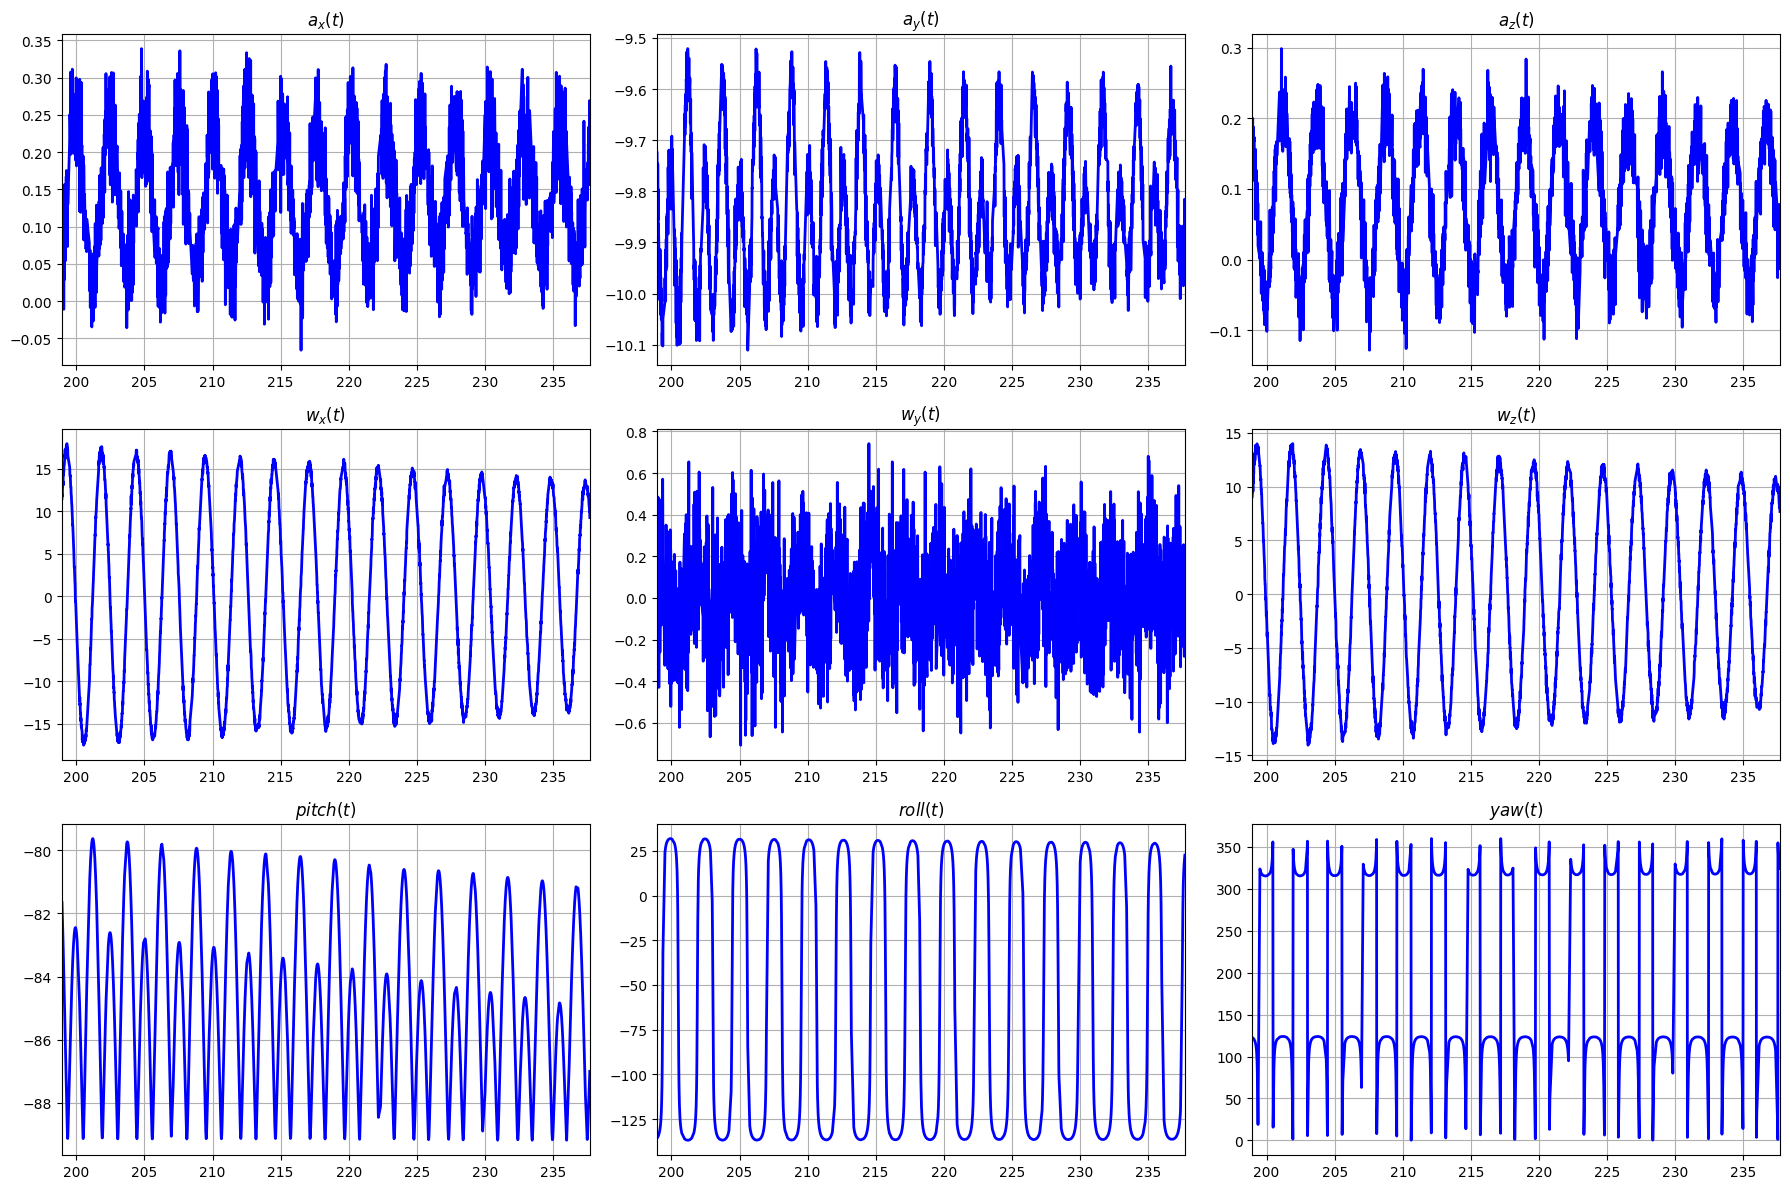

In [64]:
df = getDataframe(TEST, TARGET)
plotAll(df, limits=VIEW_LIMITS)

In [65]:
df.head()

,az,wx,wz,yaw,ay,time,ax,e,roll,wy,pitch
0,0.010817,0.05242,-0.23137,83.617,-9.838904,5.072,0.152513,0.0,-94.338,-0.13189,-89.244
1,0.033411,-0.28030,0.00031,83.489,-9.812024,5.082,0.187895,0.0,-94.209,0.05542,-89.244
2,-0.000049,0.26531,-0.17762,83.545,-9.722685,5.092,0.151268,0.0,-94.265,0.56119,-89.245
3,-0.082415,-0.09454,-0.31389,83.423,-9.756930,5.102,0.083131,0.0,-94.144,-0.40448,-89.244
4,0.058791,-0.12867,0.22484,83.327,-9.750144,5.112,0.150856,0.0,-94.048,0.05397,-89.245


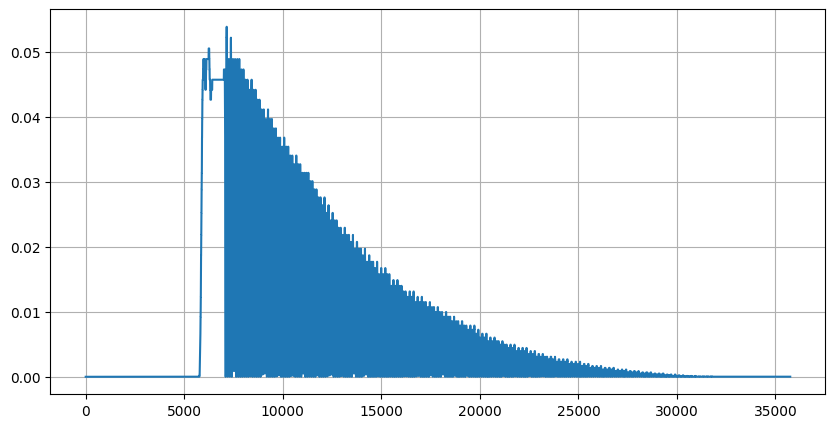

In [66]:
L = 1.0
df['true_heave'] = L * (1 - np.cos(np.deg2rad(df.e.values)))

plt.figure(figsize=(10, 5))
plt.plot(df.true_heave)
plt.grid()

Text(0.5, 1.0, 'Final MRU Heave Output vs True Physical Heave')

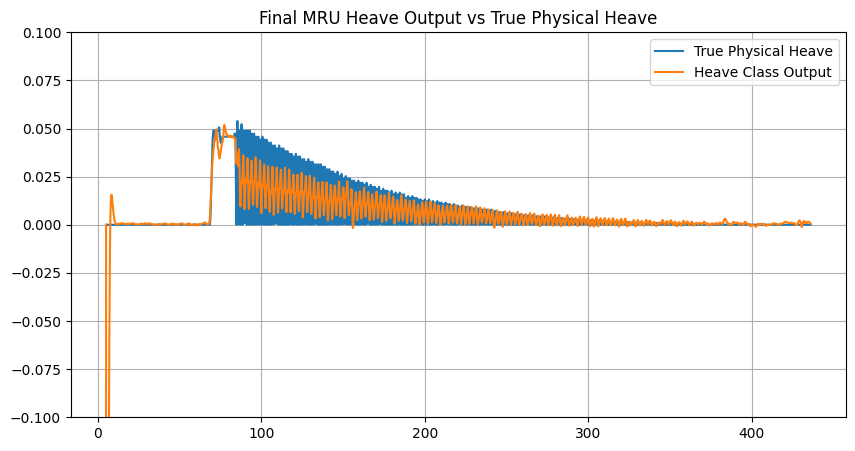

In [68]:
from heave import Heave
import numpy as np
import matplotlib.pyplot as plt

heave_obj = Heave()
calc_heave = np.zeros(len(df))

wx = df.wx.values
wy = df.wy.values
wz = df.wz.values
ax = df.ax.values
ay = df.ay.values
az = df.az.values
pitch = df.pitch.values
roll = df.roll.values
time = df.time.values * 1000000.0

for i in range(len(df)):
    heave_obj.update(wx[i], wy[i], wz[i], ax[i], ay[i], az[i], pitch[i], roll[i], time[i])
    calc_heave[i] = heave_obj.value

df['calc_heave'] = calc_heave

plt.figure(figsize=(10, 5))
df['true_heave'] = 1.0 * (1 - np.cos(np.deg2rad(df.e.values)))
plt.plot(df.time, df.true_heave, label='True Physical Heave')
plt.plot(df.time, df.calc_heave, label='Heave Class Output')
plt.ylim(-0.1, 0.1)
plt.legend()
plt.grid()
plt.title('Final MRU Heave Output vs True Physical Heave')
